# **Macro Drivers of Learning**

**Question** What factors can explain the difference in LAYS achieved by countries with similar levels of expenditure? 

From analysis of spending, income and LAYS we can see that increased spending does not predict increased LAYS for low-income countries, and even where there is a strong correlation for higher-income countries, much of the variance in performance cannot be explained by GDP per capita or expenditure alone. 

Before we look at ***what budgets are spent on*** we should pay attention to macro factors in the education system as well as outside of the education system that may explain challenges in converting additional funding to additional achievement. 

For this, the factors which we will explore are:

1. **State Fragility**: This will be based on the Fragile States Index (FSI). We will use the overall index as a proxy for the stability of state infrastructure, which theoretically may impact the efficiency of spending
2. **School Aged Population (SAP)**: The raw figure will be used as a proxy for size of the education system, with the theory being that larger systems may be more efficient in converting spending into LAYS.
3. **SAP Proportion**: This is the proportion of the population which is school aged, giving us a proxy for rapid population growth, and therefore the need to rapidly expand the education system, which may lead to pressure on infrastructure. 
4. **Language Fractionalisation**: This is taken from Alesina et al (2003) index of language fractionalisation which provides a figure for the likelihood of two people in a given country not speaking the same language. We use this as a proxy for the likelihood that a child won't speak the language of instruction, with the theory being that increased language fractionalisation is a challenge for education systems, reducing the effectiveness of investments. 
4. **Household Expenditure on Education**: This will help us get a sense of the "true" budget for education. While data on household spending is potentially unreliable, it can help to see whether countries which look like they are overperforming compared to spending may be reliant on significant household expenditure. 
5. **Enrolment in private Schools**: Similar to household spending, this may show us that countries are reliant on private expenditure on education. 

For this, our outcome variable will be the residual variance not explained by either a) GDPPC or b) PCT Budget spent on education. This will allow us firstly to visually map countries which over (or under) perform given their level of wealth/spending. 

We will use simple OLS regression, starting with a complete model. For interpretability, we will standardise our outcome variable to allow us to give standardised effect sizes and confidence intervals. Where there is significant multicoliearity (measured by a Variance Inflation Factor above 5) we will remove variables to find our final model. 

In [1]:
#========================================
# Import required packages
#========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle, Ellipse
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from pathlib import Path
import json
import sys
sys.path.append(r"C:\Users\F.Turner\Documents\00. Analyses")
import use_funcs
from use_funcs import find_project_root

In [12]:
#========================================
# Define Save the Children colour palette
#========================================

sc_colors = {'red': '#da291c',
             'medium red' : '#ed7b73',
             'light red': '#f9d3d0',
             'purple': '#ae90c3',
             'medium purple': '#cebcdb',
             'light purple': '#efe9f3',
             'yellow': '#fecf28',
             'medium yellow': '#ffeca9',
             'light yellow': '#fff5d4',
             'blue': '#99cccc',
             'medium blue' : '#d6ebeb',
             'light blue' : '#ebf5f5',
             'green' : '#45b283',
             'medium green' : '#8dd3b5',
             'light green' : '#d9f0e6',
             'grey' : '#e7e6e6'}

mpl.rcParams['font.family'] = 'Calibri' 

ig_palette = {
        "Low income": sc_colors["green"],
        "Lower middle income": sc_colors["red"],
        "Upper middle income": sc_colors["purple"],
        "High income": sc_colors["blue"],
    }

In [3]:
#========================================
# Configure project paths and output folders
#========================================

PROJECT_ROOT = find_project_root(Path.cwd())
CONFIG_PATH = PROJECT_ROOT / "path_config.json"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    PATHS = json.load(f)

IMP_DIR = (PROJECT_ROOT / PATHS["imports_dir"]).resolve()
HO_DIR = (PROJECT_ROOT / PATHS["handoff_dir"]).resolve()
EXP_DIR = (PROJECT_ROOT / PATHS["exports_dir"]).resolve()
FIG_DIR = (PROJECT_ROOT / PATHS["figures_dir"]).resolve()
TAB_DIR = (PROJECT_ROOT / PATHS["tables_dir"]).resolve()

for folder in [IMP_DIR, HO_DIR, EXP_DIR, FIG_DIR, TAB_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IMP_DIR:", IMP_DIR)
print("HO_DIR:", HO_DIR)
print("EXP_DIR:", EXP_DIR)
print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

PROJECT_ROOT: C:\Users\F.Turner\Documents\00. Analyses\Education Financing
IMP_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Data
HO_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Handoff
EXP_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results
FIG_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results\figures
TAB_DIR: C:\Users\F.Turner\Documents\00. Analyses\Education Financing\Results\tables


In [4]:
def standardise(series):
    """
    Standardise a pandas Series to mean 0 and SD 1.
    """
    return (series - series.mean()) / series.std(ddof=0)


In [5]:
#========================================
# Load core analysis datasets
#========================================

all_data = pd.read_csv(IMP_DIR / "all_data.csv")
lays_panels = pd.read_csv(IMP_DIR / "lays_panels.csv")

## Prepare Data for Analysis and Check Sample Size

In [51]:
df_base = all_data.copy()
df_base = df_base[df_base['income_group'] != 'Not classified']
df_base = df_base.sort_values("year", ascending=False).groupby("iso3").first().reset_index()
df_base = df_base.dropna(subset=["lays", "expenditure_perchild_ppp"])
df_base['log_gdppc'] = np.log(df_base['gdppc_2015_usd'])
df_base['log_spending'] = np.log(df_base['expenditure_perchild_ppp'])

# Step 2: Fit base model — LAYS explained by income and spending
X_base = sm.add_constant(df_base[["log_spending"]])
y_base = df_base["lays"]
model_base = sm.OLS(y_base, X_base).fit()

print(model_base.summary())

X_base = sm.add_constant(df_base[["log_gdppc"]])
y_base = df_base["lays"]
model_base2 = sm.OLS(y_base, X_base).fit()

print(model_base2.summary())

# Step 3: Extract residuals as the new outcome variable
df_base["lays_residual"] = model_base2.resid

                            OLS Regression Results                            
Dep. Variable:                   lays   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     247.1
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.74e-31
Time:                        17:12:52   Log-Likelihood:                -228.04
No. Observations:                 128   AIC:                             460.1
Df Residuals:                     126   BIC:                             465.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -2.7192      0.696     -3.904   

In [52]:
#============================================
# Prepare sample for additional-driver model
#============================================

df = df_base.copy()

df = df.drop(df[df['income_group'] == 'Not classified'].index, axis=0)
df = df[["iso3", 
         'income_group',
         "year", 
         "lays_residual", 
         'fsi_total',
         'sap', 
         'sap_share',
         'lang_frac',
         'hh_exp_pct',
         'private_enrolment_pct',
         'expenditure_pctgdp',
         "gdppc_2015_usd",
         'expenditure_pctbudget_uis'
        ]]



df = df.sort_values("year", ascending=False)
df = df.groupby("iso3").agg('first').reset_index()
df['log_gdppc'] = np.log(df['gdppc_2015_usd'])
df = df.drop(columns=['gdppc_2015_usd']).copy()

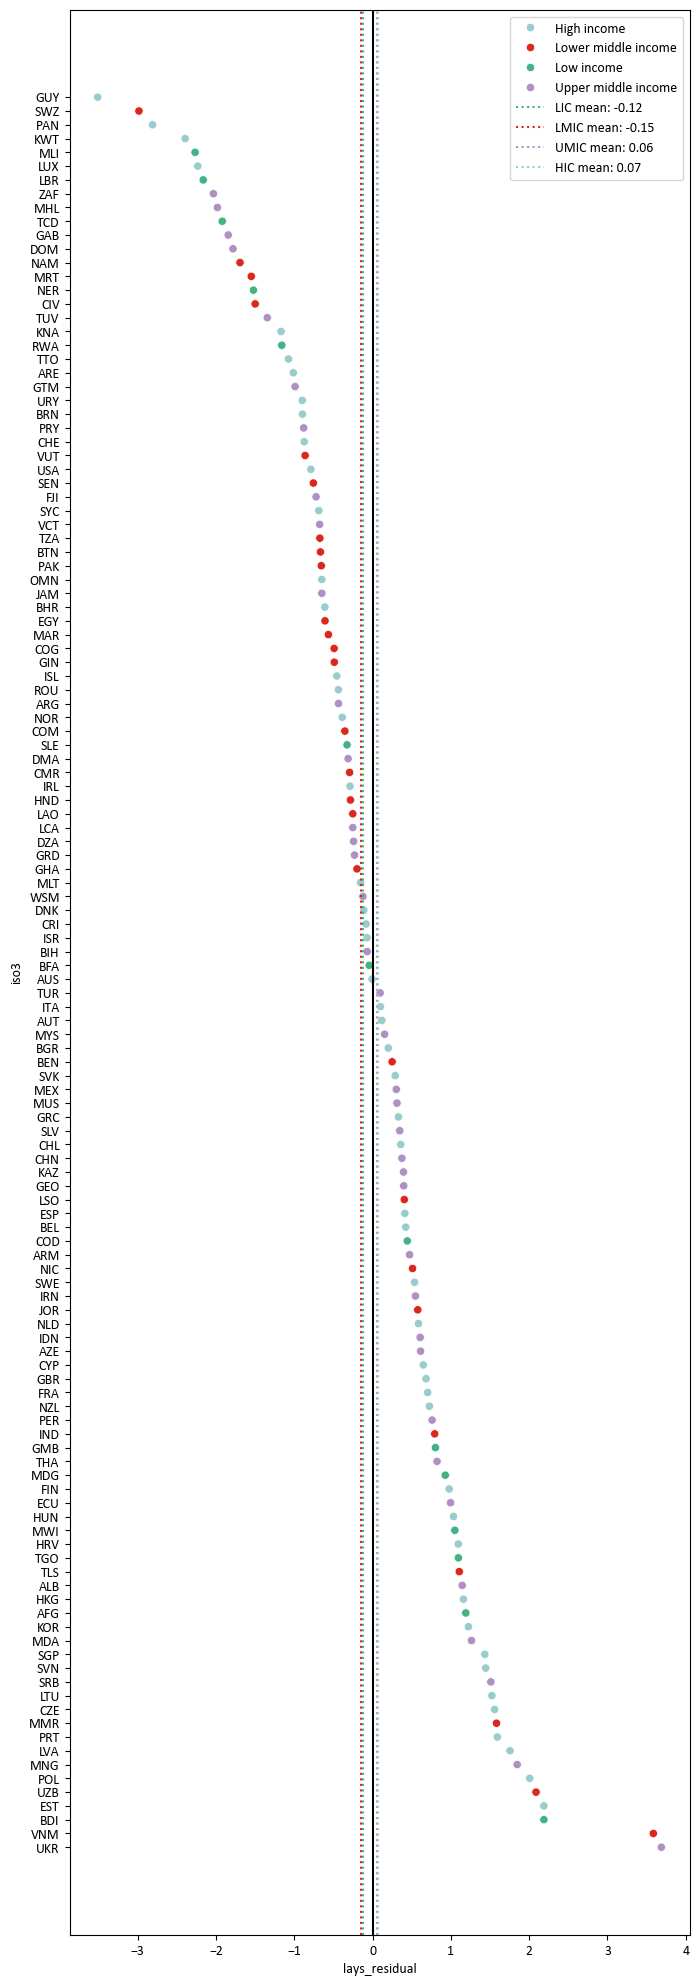

In [53]:
#==============================================================
# Visualise LAYS Residuals against zero and by income group
#==============================================================


fig, ax = plt.subplots(figsize=(8, 25))

work = df.copy()
work = work.sort_values("lays_residual", ascending=True)

lic_mean = work[work['income_group'] == "Low income"]['lays_residual'].mean()
lmic_mean = work[work['income_group'] == "Lower middle income"]['lays_residual'].mean()
umic_mean = work[work['income_group'] == "Upper middle income"]['lays_residual'].mean()
hic_mean = work[work['income_group'] == "High income"]['lays_residual'].mean()

sns.scatterplot(data=work, x="lays_residual", y="iso3", hue="income_group", palette=ig_palette, ax=ax)
ax.axvline(0, color='black', linestyle='-')

ax.axvline(lic_mean, color=ig_palette["Low income"], linestyle=':', label=f"LIC mean: {lic_mean:.2f}")
ax.axvline(lmic_mean, color=ig_palette["Lower middle income"], linestyle=':', label=f"LMIC mean: {lmic_mean:.2f}")
ax.axvline(umic_mean, color=ig_palette["Upper middle income"], linestyle=':', label=f"UMIC mean: {umic_mean:.2f}")
ax.axvline(hic_mean, color=ig_palette["High income"], linestyle=':', label=f"HIC mean: {hic_mean:.2f}")

ax.legend()

In [57]:
#=========================================================
# Standardise continuous variables for regression analysis
#=========================================================

continuous_vars = ['lays_residual', "log_gdppc", 'fsi_total', 'sap', 'sap_share', 'lang_frac', 'hh_exp_pct', 'private_enrolment_pct', 'expenditure_pctbudget_uis']
for var in continuous_vars:
    df[f'z_{var}'] = standardise(df[var])

In [58]:
display(df[[ "z_lays_residual", "z_log_gdppc", "z_expenditure_pctbudget_uis", "z_fsi_total", "z_sap_share", 'z_sap', 'z_sap_share', 'z_lang_frac', 'z_hh_exp_pct', 'z_private_enrolment_pct']].info())

df = df.dropna().copy()

display(df.groupby("income_group").agg('size').reset_index().copy())

df.info()


<class 'pandas.DataFrame'>
Index: 96 entries, 1 to 124
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   z_lays_residual              96 non-null     float64
 1   z_log_gdppc                  96 non-null     float64
 2   z_expenditure_pctbudget_uis  96 non-null     float64
 3   z_fsi_total                  96 non-null     float64
 4   z_sap_share                  96 non-null     float64
 5   z_sap                        96 non-null     float64
 6   z_sap_share                  96 non-null     float64
 7   z_lang_frac                  96 non-null     float64
 8   z_hh_exp_pct                 96 non-null     float64
 9   z_private_enrolment_pct      96 non-null     float64
dtypes: float64(10)
memory usage: 8.2 KB


None

,income_group,0
0,High income,42
1,Low income,10
2,Lower middle income,21
3,Upper middle income,23


<class 'pandas.DataFrame'>
Index: 96 entries, 1 to 124
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   iso3                         96 non-null     str    
 1   income_group                 96 non-null     str    
 2   year                         96 non-null     int64  
 3   lays_residual                96 non-null     float64
 4   fsi_total                    96 non-null     float64
 5   sap                          96 non-null     float64
 6   sap_share                    96 non-null     float64
 7   lang_frac                    96 non-null     float64
 8   hh_exp_pct                   96 non-null     float64
 9   private_enrolment_pct        96 non-null     float64
 10  expenditure_pctgdp           96 non-null     float64
 11  expenditure_pctbudget_uis    96 non-null     float64
 12  log_gdppc                    96 non-null     float64
 13  z_lays_residual              96 non-n

**Observations**

Including all of the variables, we have 106 countries for which we have data. Only 10 of these are low-income countries, as compared to 16 for which we have lays data from. For our initial analysis this is acceptable. If we need to remove variables it is likely that this sample will increase. 

## Regression Analysis

In [59]:
work = df.drop(columns=continuous_vars)

In [60]:
#================================================
# Fit multivariable OLS with additional controls
#================================================

y = work['z_lays_residual']

X = work[["z_expenditure_pctbudget_uis", "z_fsi_total", "z_sap_share", 'z_sap', 'z_lang_frac', 'z_hh_exp_pct', 'z_private_enrolment_pct']]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print("=" * 80)
print("Table 2a: OLS regression results for model with additional controls")
print("=" * 80)
print("\n")

print(model.summary())

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print("\n")
print("=" * 100)
print("Table 2b: Variance Inflation Factors (VIF) for regression model with additional controls")
print("=" * 100)
print("\n")

print(vif)

Table 2a: OLS regression results for model with additional controls


                            OLS Regression Results                            
Dep. Variable:        z_lays_residual   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     3.242
Date:                Wed, 20 May 2026   Prob (F-statistic):            0.00416
Time:                        17:13:32   Log-Likelihood:                -125.20
No. Observations:                  96   AIC:                             266.4
Df Residuals:                      88   BIC:                             286.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

Table 2a: OLS Regression of Residual LAYS on Macro Drivers

This model uses standardised LAYS residuals as the outcome. Residuals are estimated from a base model of LAYS on log GDP per capita, so the dependent variable represents over- or under-performance in learning relative to what country income predicts.

The coefficients can be interpreted as associations with this over-/under-performance gap. A positive coefficient indicates that higher values of that driver are associated with countries performing above their income-predicted LAYS level; a negative coefficient indicates association with under-performance relative to income-predicted LAYS.

The model includes education budget share (% of government budget), fragility, school-aged population share, total school-aged population, language fractionalisation, household education expenditure, and private enrolment. Table 2b reports VIF values to check multicollinearity across these predictors.

Interpretation should focus on which macro factors are significantly associated with residual performance after accounting for income. This allows us to identify structural conditions linked to countries converting available resources into learning outcomes more (or less) effectively.

## Visualisation of Standardised Coefficients

In [62]:
#=========================================
# Create data frame for visualisation 
#=========================================

model_df = pd.DataFrame({
    "Variable": ["Education expenditure (% of budget)", 
                 "Fragility \n(Fragile States Index Score)", 
                 "SAP share of total population \n(SAP share)", 
                 "School Aged Population \n(SAP)", 
                 "Language Fractionalisation \n(Language fractionalisation index)",
                 "Household expenditure on education \n(% of total)", 
                 "Private enrolment \n(% of total)"],
    "Coefficient": model.params[1:].values,
    "CI Lower": model.conf_int().iloc[1:, 0].values,
    "CI Upper": model.conf_int().iloc[1:, 1].values,
    "Significant": model.pvalues[1:].values < 0.05
})

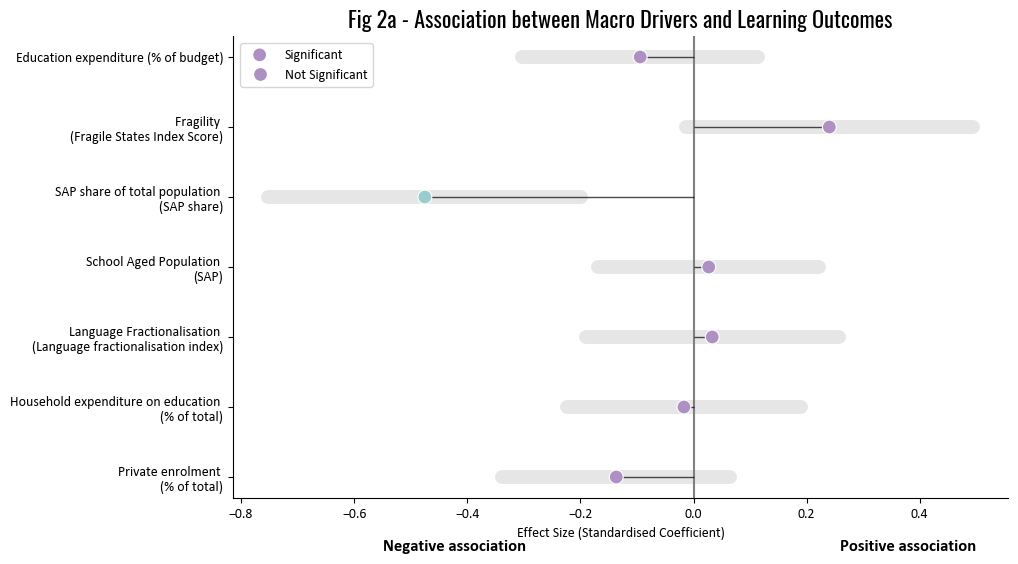

In [64]:
#========================================================================
# Create regression coefficient plot for model with additional controls
#========================================================================

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor('white')

# ax.errorbar(x=model_df["Coefficient"], y=model_df["Variable"], xerr=[model_df["Coefficient"] - model_df["CI Lower"], model_df["CI Upper"] - model_df["Coefficient"]], fmt='none', elinewidth=10, ecolor=sc_colors['grey'], capsize=0, zorder=0)
sns.scatterplot(x=model_df["Coefficient"], y=model_df["Variable"], hue=model_df["Significant"], palette={True: sc_colors['blue'], False: sc_colors['purple']}, s=100, ax=ax, zorder=2)

ax.axvline(x=0, color='grey', linestyle='-', zorder=1)

ax.set_facecolor('white')

ax.text(0.5, 7, "Positive association", color='black', fontsize=12, fontweight='bold', va='center', ha='right')
ax.text(-0.55, 7, "Negative association", color='black', fontsize=12, fontweight='bold', va='center', ha='left')

ax.hlines(model_df['Variable'], 0, model_df['Coefficient'], color="black", linestyles="-", linewidth=1, alpha=0.7, zorder=1)

ax.hlines(y=model_df['Variable'],
    xmin=model_df['CI Lower'],
    xmax=model_df['CI Upper'],
    linewidth=10,
    capstyle="round",
    color=sc_colors['grey'],
    zorder=0
)

plt.xlabel("Effect Size (Standardised Coefficient)")
plt.title("Fig 2a - Association between Macro Drivers and Learning Outcomes", fontname='Oswald', fontsize=16)
plt.legend(loc='upper left', labels=['Significant', 'Not Significant'])
ax.spines[['right','top']].set_visible(False)
ax.set_ylabel('')
plt.show()

Fig 2a: Association between Macro Drivers and Learning Outcomes

This figure shows the coefficients from Table 2a, with statistically significant effects shown in green, and error bars marking the confidence intervals. This highlights that the statisticaly significance of household spending on education is marginal, with the 95 percent confidence interval close to a zero effect. 